  Both HB levels  12K  0.97 [0.91-1.03]     
  Both HB levels  17K  1.04 [0.99-1.09]     
  Both HB levels  6K   0.88 [0.81-0.95]  ** 
  Both HB levels  28K  0.87 [0.84-0.91]  ***
  Both HB levels  20K  0.91 [0.87-0.95]  ***
  Both HB levels  15K  0.98 [0.92-1.03]     
  Both HB levels  74K  0.73 [0.71-0.74]  ***
  Both HB levels  28K  0.78 [0.75-0.81]  ***
  Both HB levels  32K   0.82 [0.79-0.85]  ***
  Both HB levels  10K   1.03 [0.97-1.09]     
  Both HB levels  14K   1.01 [0.96-1.06]     
  Both HB levels  143K  0.85 [0.84-0.87]  ***
  Both HB levels  23K  0.89 [0.86-0.93]  ***
  Both HB levels  9K   0.96 [0.90-1.01]     
  Both HB levels  31K  0.85 [0.82-0.88]  ***
  Both HB levels  52K  0.83 [0.81-0.85]  ***
Figure saved to: paper/figures/or_all_flagged_vs_unflagged.pdf


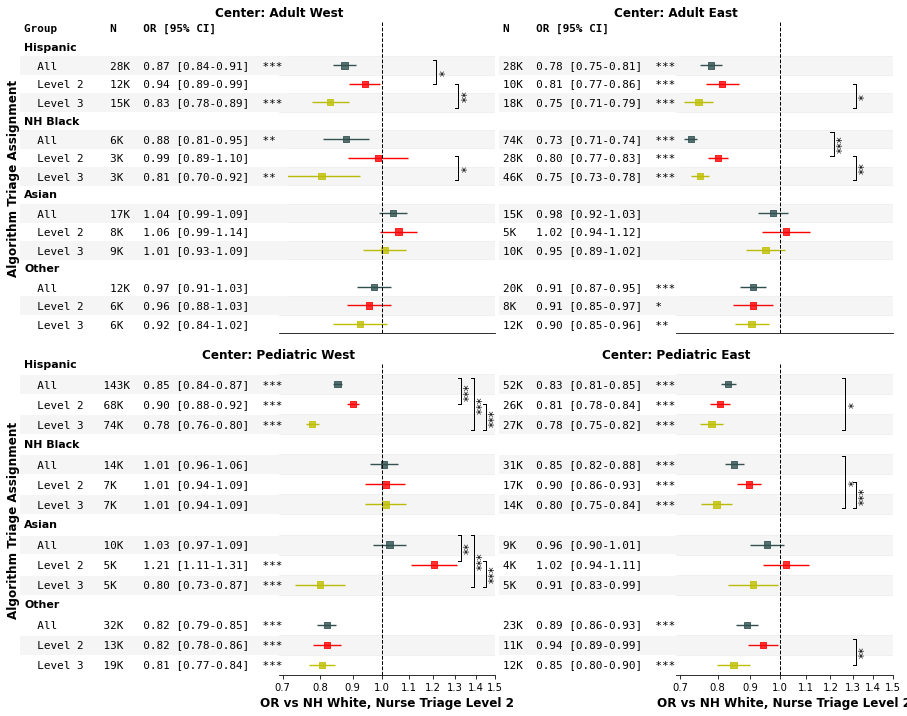

In [21]:
from plot import forest_plot
mode='flagged_vs_unflagged'

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import copy
from pathlib import Path 
import os

centers = [
    'Stanford', 
    'BIDMC', 
    'CHLA',
    'BCH'
]
centerlabel = {
    'BIDMC': 'Adult East', 
    'Stanford': 'Adult West', 
    'BCH': 'Pediatric East', 
    'CHLA': 'Pediatric West'
}
# mode = 'all_combinations'  # 'flagged_vs_unflagged', 'all_combinations'
mode = 'flagged_vs_unflagged'
# results_prefix='results_hispanic-thresholded'
results_prefix='results'

fig, axes = plt.subplots(2,2, figsize=(11, 12))

i=0
for row,axr in enumerate(axes):
    for col,ax in enumerate(axr):
        center = centers[i]
        i+=1
        # Call main function with correct parameters and pass ax through plot_kwargs
        results_dir=f'{results_prefix}/{center}/{mode}'
        forest_plot(results_dir, ax=ax)
    
        # Plotting customization code
        ax.tick_params(axis='y', which='both', pad=251 if col == 0 else 170)
        ax.set_title(f'Center: {centerlabel[center]}', fontweight='bold', loc='center', fontsize=12, x=0) #, y=1.0, pad=-10 if row==0 else -1)
        if row == 1: 
            # makes y column labels appear
            ax.set_ylim(top=15)
        # ax.text(0,0, centerlabel[center],fontsize=12,rotation=90)
        # plt.text(0,0, 'test',fontsize=12,rotation=90)
        if row == 0:
            ax.set_xlabel('')
            ax.tick_params(axis='x', which='both', bottom=False,labelbottom=False)
        else:
            # print(ax.get_xticklabels())
            ax.set_xlabel('OR vs NH White, Nurse Triage Level 2')
        # Label customization
        shade = False
        labels = ax.get_yticklabels()
            
        for label in ax.get_yticklabels():
            if 'Both HB' in label._text:
                print(label.get_text())
                label.set_text(label._text.replace('Both HB levels','All           '))
            if 'Variable' in label._text:
                label.set_text(label._text.replace('Variable','Group   '))
            label.set_text(
                label._text
                .replace('HB level 2','Level 2   ')
                .replace('HB level 3','Level 3   ')
            )
            if center=='CHLA':
                label.set_text(
                    label._text
                    .replace('All          ','All    ')
                    .replace('Level 2      ','Level 2')
                    .replace('Level 3      ','Level 3')
                )
            else:
                label.set_text(
                    label._text
                    .replace('Group        ','Group   ')
                    .replace('All          ','All     ')
                    .replace('Level 2      ','Level 2 ')
                    .replace('Level 3      ','Level 3 ')
                )
        # for label in ax.get_yticklabels():
        #     label.set_text(
        #         label._text
        #         .replace('All          ','All     ')
        #         .replace('Level 2      ','Level 2 ')
        #         .replace('Level 3      ','Level 3 ')
        #         # .replace('HB level 3','Level 3   ')
        #     )
        if col==1:
            for label in labels:
                label.set_text(label._text[13:])
        ax.set_yticklabels(labels)
    
        # Styling
        for label in ax.get_yticklabels():
            plt.setp(label,fontsize=11,linespacing=1.,va='center') #,edgecolor='w') 
            if label.get_fontweight() == 'bold': 
                shade=True
                continue
            fc = 'whitesmoke' if shade else 'w'
            # label._bbox_patch = FancyBboxPatch((0, 0), width=1000, height=5,fc=fc, ec='lightgray', boxstyle='round') 
            if shade:
                plt.setp(label, backgroundcolor='whitesmoke')
            shade= not shade
        color_wheel = ['k','k','k','r','r','r','orange','orange','orange']
    
        # Color customization
        color_wheel = [
            'y',
            'r',
            'darkslategray',
            'k',
            'y',
            'r',
            'darkslategray',
            'k',
            'y',
            'r',
            'darkslategray',
            'k',
            'y',
            'r',
            'darkslategray'
        ]
        
        for collection in ax.collections:
            cw = copy.copy(color_wheel)
            if hasattr(collection,'set_facecolors'):
                collection.set_facecolors(cw)
            if hasattr(collection,'set_edgecolors'):
                collection.set_edgecolors(color_wheel)
    
        ax.set_xlim(0.69, 1.5)
        ax.set_xticks(
            [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3,1.4, 1.5],
            ['0.7', '0.8', '0.9', '1.0', '1.1', '1.2', '1.3','1.4', '1.5'],
                     )
        # for k,v in ax.spines._dict.items():
        #     if k in ['top']:
        #         continue
        #     v.set_color('whitesmoke' if k=='left' else 'k')
        #     v.set_linewidth(1)
        #     v.set_visible(True)
        if col==0:
            ax.set_ylabel('Algorithm Triage Assignment',fontweight='bold', fontsize=12)
# fig.subplots_adjust(hspace=0.06,wspace=0.57)
fig.subplots_adjust(hspace=0.1,wspace=0.84)

# Save figure
os.makedirs('paper/figures/', exist_ok=True)
savename = f'paper/figures/or_all_{mode}.pdf'
fig.savefig(savename, bbox_inches='tight')
print(f"Figure saved to: {savename}")
plt.show()

# ax = axes[0]
# ax.get_yticklabels()
# y = ax.get_yticklabels()[1]
# vars(ax)
# print(y._bbox_patch)
# vars(ax)
# ax.get_ylim()
# print(len(ax._children))
# print(len(ax.get_yticklabels()))

# vars(ax._children[0]._marker)
# dir(ax.collections[0])
# collection = ax.collections[0]

# dir(collection)

  Both HB levels  12K  0.97 [0.91-1.03]     
  Both HB levels  17K  1.04 [0.99-1.09]     
  Both HB levels  6K   0.88 [0.81-0.95]  ** 
  Both HB levels  28K  0.87 [0.84-0.91]  ***
  Both HB levels  20K  0.91 [0.87-0.95]  ***
  Both HB levels  15K  0.98 [0.92-1.03]     
  Both HB levels  74K  0.73 [0.71-0.74]  ***
  Both HB levels  28K  0.78 [0.75-0.81]  ***
  Both HB levels  32K   0.82 [0.79-0.85]  ***
  Both HB levels  10K   1.03 [0.97-1.09]     
  Both HB levels  14K   1.01 [0.96-1.06]     
  Both HB levels  143K  0.85 [0.84-0.87]  ***
  Both HB levels  23K  0.89 [0.86-0.93]  ***
  Both HB levels  9K   0.96 [0.90-1.01]     
  Both HB levels  31K  0.85 [0.82-0.88]  ***
  Both HB levels  52K  0.83 [0.81-0.85]  ***
Figure saved to: paper/figures/or_all_flagged_vs_unflagged_no_numbers.pdf


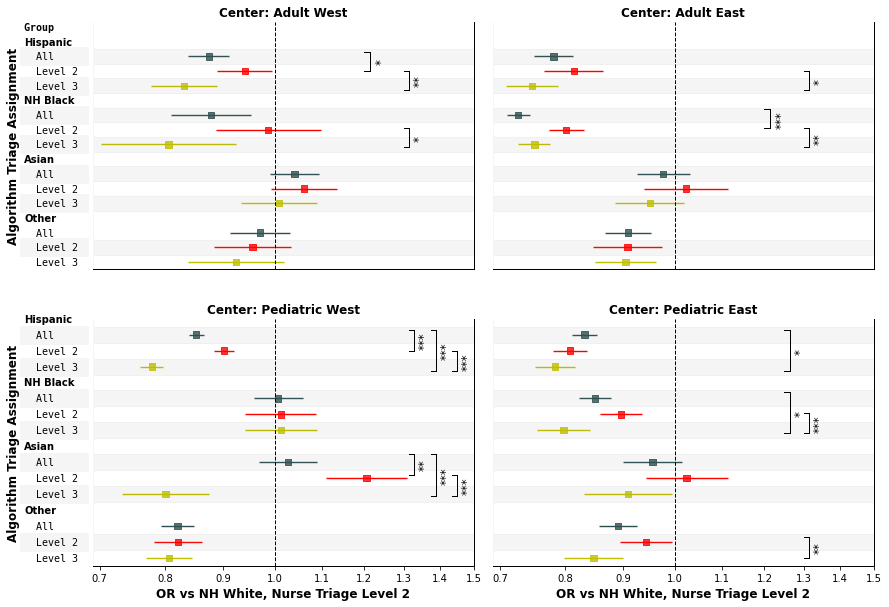

In [2]:
from plot import forest_plot
mode='flagged_vs_unflagged'

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import copy
from pathlib import Path 
import os

centers = [
    'Stanford', 
    'BIDMC', 
    'CHLA',
    'BCH'
]
centerlabel = {
    'BIDMC': 'Adult East', 
    'Stanford': 'Adult West', 
    'BCH': 'Pediatric East', 
    'CHLA': 'Pediatric West'
}
# mode = 'all_combinations'  # 'flagged_vs_unflagged', 'all_combinations'
mode = 'flagged_vs_unflagged'
# results_prefix='results_hispanic-thresholded'
results_prefix='results'

fig, axes = plt.subplots(2,2, figsize=(14, 10))

i=0
for row,axr in enumerate(axes):
    for col,ax in enumerate(axr):
        center = centers[i]
        i+=1
        # Call main function with correct parameters and pass ax through plot_kwargs
        results_dir=f'{results_prefix}/{center}/{mode}'
        forest_plot(results_dir, ax=ax)
    
        # Plotting customization code
        ax.tick_params(axis='y', which='both', pad=65 if col == 0 else 10)
        # ax.set_title(f'Center: {centerlabel[center]}', fontweight='bold', loc='center', fontsize=12, y=1.0, pad=-10 if row==0 else 0)
        ax.set_title(f'Center: {centerlabel[center]}', fontweight='bold', loc='center', fontsize=12)
        if row == 1: 
            # makes y column labels appear
            ax.set_ylim(top=15)
        # ax.text(0,0, centerlabel[center],fontsize=12,rotation=90)
        # plt.text(0,0, 'test',fontsize=12,rotation=90)
        if row == 0:
            ax.set_xlabel('')
            ax.tick_params(axis='x', which='both', bottom=False,labelbottom=False)
        else:
            # print(ax.get_xticklabels())
            ax.set_xlabel('OR vs NH White, Nurse Triage Level 2')
        # Label customization
        shade = False
        labels = ax.get_yticklabels()
            
        for label in labels:
            if 'Both HB' in label._text:
                print(label.get_text())
                label.set_text(label._text.replace('Both HB levels','All    '))
            if 'Variable' in label._text:
                label.set_text(label._text.replace('Variable','Group   '))
            label.set_text(
                label._text
                .replace('HB level 2','Level 2')
                .replace('HB level 3','Level 3')
            )
        for label in labels:
            label.set_text(label._text[:10])
        ax.set_yticklabels(labels)
        if col==1:
            ax.set_yticklabels([])
            # for label in labels:
            #     label.set_text(label._text[13:])
    
        # Styling
        for label in ax.get_yticklabels():
            plt.setp(label,fontsize=10,linespacing=1.,va='center') #,edgecolor='w') 
            if label.get_fontweight() == 'bold':
                shade=True
                continue
            fc = 'whitesmoke' if shade else 'w'
            # label._bbox_patch = FancyBboxPatch((0, 0), width=1000, height=5,fc=fc, ec='lightgray', boxstyle='round') 
            if shade:
                plt.setp(label, backgroundcolor='whitesmoke')
            shade= not shade
        color_wheel = ['k','k','k','r','r','r','orange','orange','orange']
    
        # Color customization
        color_wheel = [
            'y',
            'r',
            'darkslategray',
            'k',
            'y',
            'r',
            'darkslategray',
            'k',
            'y',
            'r',
            'darkslategray',
            'k',
            'y',
            'r',
            'darkslategray'
        ]
        
        for collection in ax.collections:
            cw = copy.copy(color_wheel)
            if hasattr(collection,'set_facecolors'):
                collection.set_facecolors(cw)
            if hasattr(collection,'set_edgecolors'):
                collection.set_edgecolors(color_wheel)
    
        ax.set_xlim(0.69, 1.5)
        ax.set_xticks(
            [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3,1.4, 1.5],
            ['0.7', '0.8', '0.9', '1.0', '1.1', '1.2', '1.3','1.4', '1.5'],
                     )
        for k,v in ax.spines._dict.items():
            if k in ['top']:
                continue
            v.set_color('whitesmoke' if k=='left' else 'k')
            v.set_linewidth(1)
            v.set_visible(True)
        if col==0:
            ax.set_ylabel('Algorithm Triage Assignment',fontweight='bold', fontsize=12)
# fig.subplots_adjust(hspace=0.06,wspace=0.57)
fig.subplots_adjust(wspace=0.05)

# Save figure
os.makedirs('paper/figures/', exist_ok=True)
savename = f'paper/figures/or_all_{mode}_no_numbers.pdf'
fig.savefig(savename, bbox_inches='tight')
print(f"Figure saved to: {savename}")
plt.show()

# ax = axes[0]
# ax.get_yticklabels()
# y = ax.get_yticklabels()[1]
# vars(ax)
# print(y._bbox_patch)
# vars(ax)
# ax.get_ylim()
# print(len(ax._children))
# print(len(ax.get_yticklabels()))

# vars(ax._children[0]._marker)
# dir(ax.collections[0])
# collection = ax.collections[0]

# dir(collection)

In [3]:
ax.spines